In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.metrics import classification_report

import numpy as np
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn import tree


from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_graphviz

from imblearn.over_sampling import SMOTE

import xgboost as xgb

import lightgbm as lgb

In [ ]:
df = pd.read_csv('WineQTMod.csv') #dataset utilizado

In [ ]:
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [ ]:
df.tail()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


# Análise Exploratória dos Dados

In [ ]:
df.shape

(1143, 13)

Verificando a quantidade de dados dados duplicados. No caso deste dataset, não há duplicações.

In [ ]:
df.duplicated().sum()

np.int64(0)

Verificando a quantidade de dados nulos. No caso deste dataset, também não há nulos.

In [ ]:
df.isnull().sum()

,0
fixed_acidity,0
volatile_acidity,0
citric_acid,0
residual_sugar,0
chlorides,0
free_sulfur_dioxide,0
total_sulfur_dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


Análise dos valores presentes na variável target quality

In [ ]:
set(df.quality)

{3, 4, 5, 6, 7, 8}

Análise dos números da variável quality:

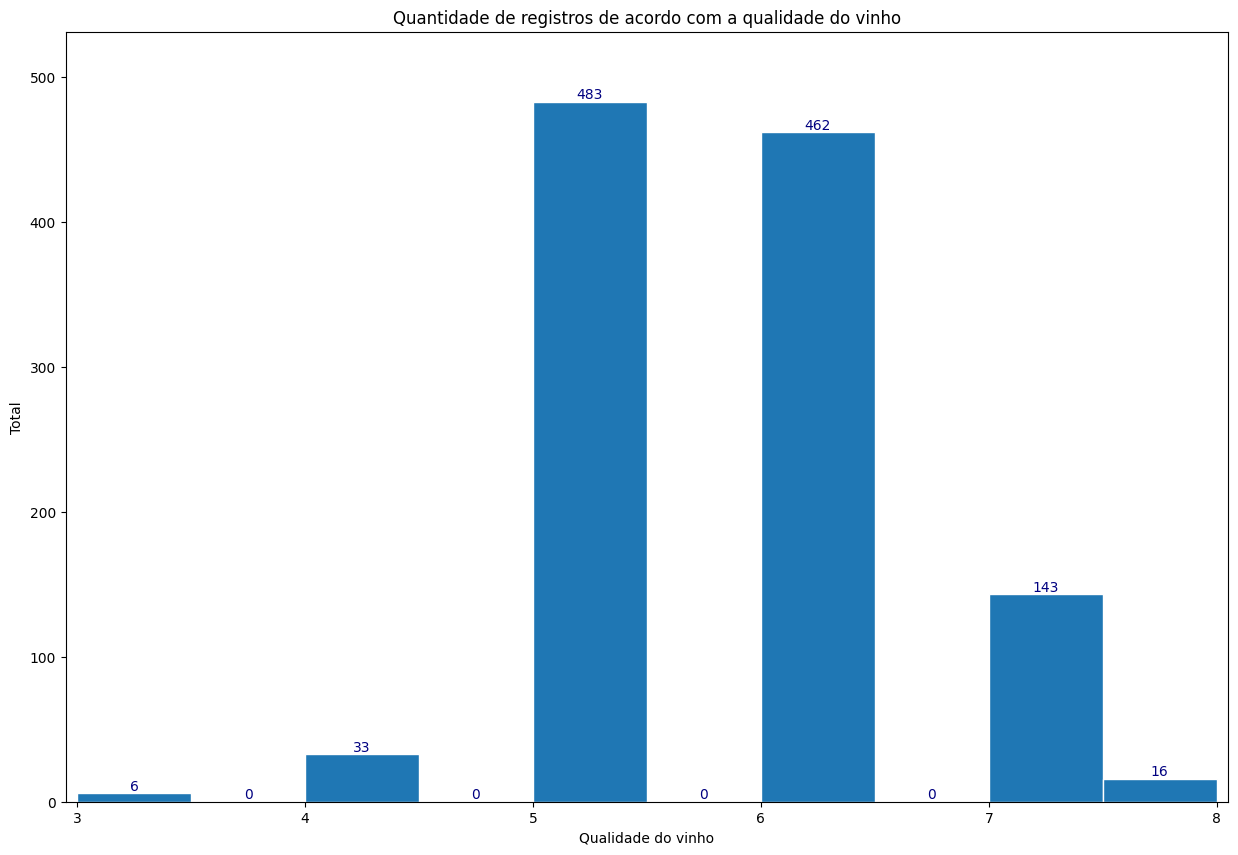

In [ ]:
plt.figure(figsize=(15, 10))
values, bins, bars = plt.hist(df['quality'], edgecolor='white')
plt.xlabel("Qualidade do vinho")
plt.ylabel("Total")
plt.title('Quantidade de registros de acordo com a qualidade do vinho')
plt.bar_label(bars, fontsize=10, color='navy')
plt.margins(x=0.01, y=0.1)
plt.show()

Remoção do Id, pois a variável não apresenta informações relevantes para as análises a seguir

In [ ]:
df = df.drop(columns=['Id'])



Verificação da correlação das variáveis



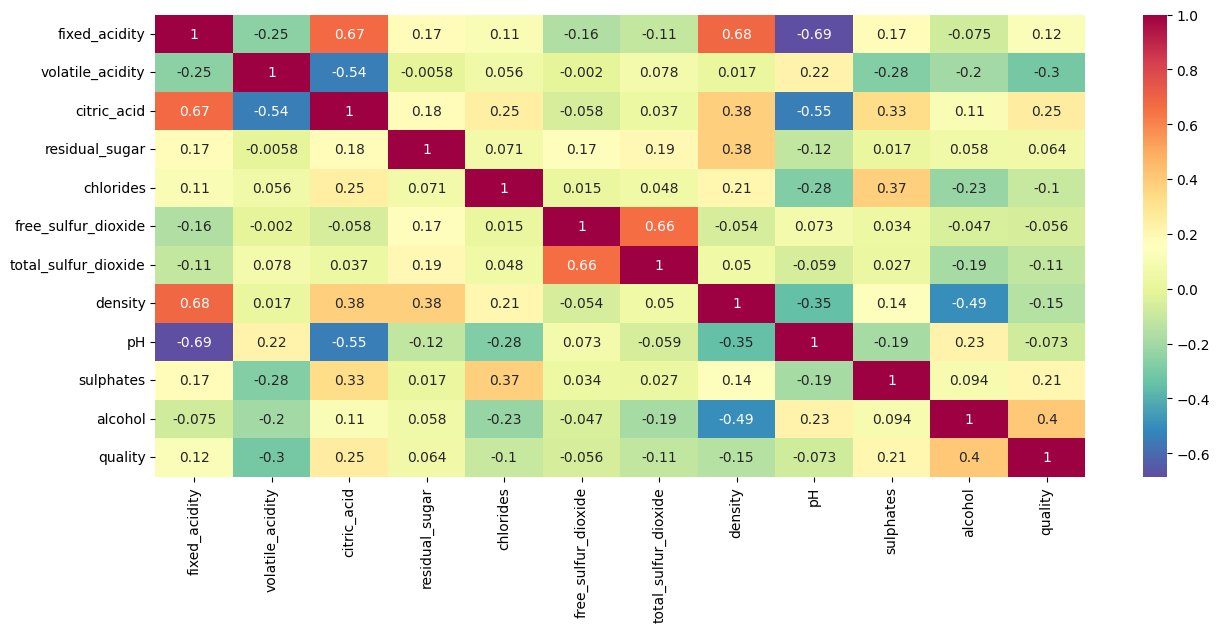

In [ ]:
#Análise de correlação das variáveis pelo heatmap

plt.figure(figsize=(15,6))
corr = sns.heatmap(df.corr(), annot = True, cmap = "Spectral_r")
plt.show()

Analisando o gráfico de heatmap, é possível perceber que algumas variáveis têm mais relação com a variável quality, o que pode ser determinante para uma nota mais alta. As relaçoes serão mais investigadas nos gráficos abaixo.



*   Correlações entre as variáveis que possuem maior proximidade com a variável quality:



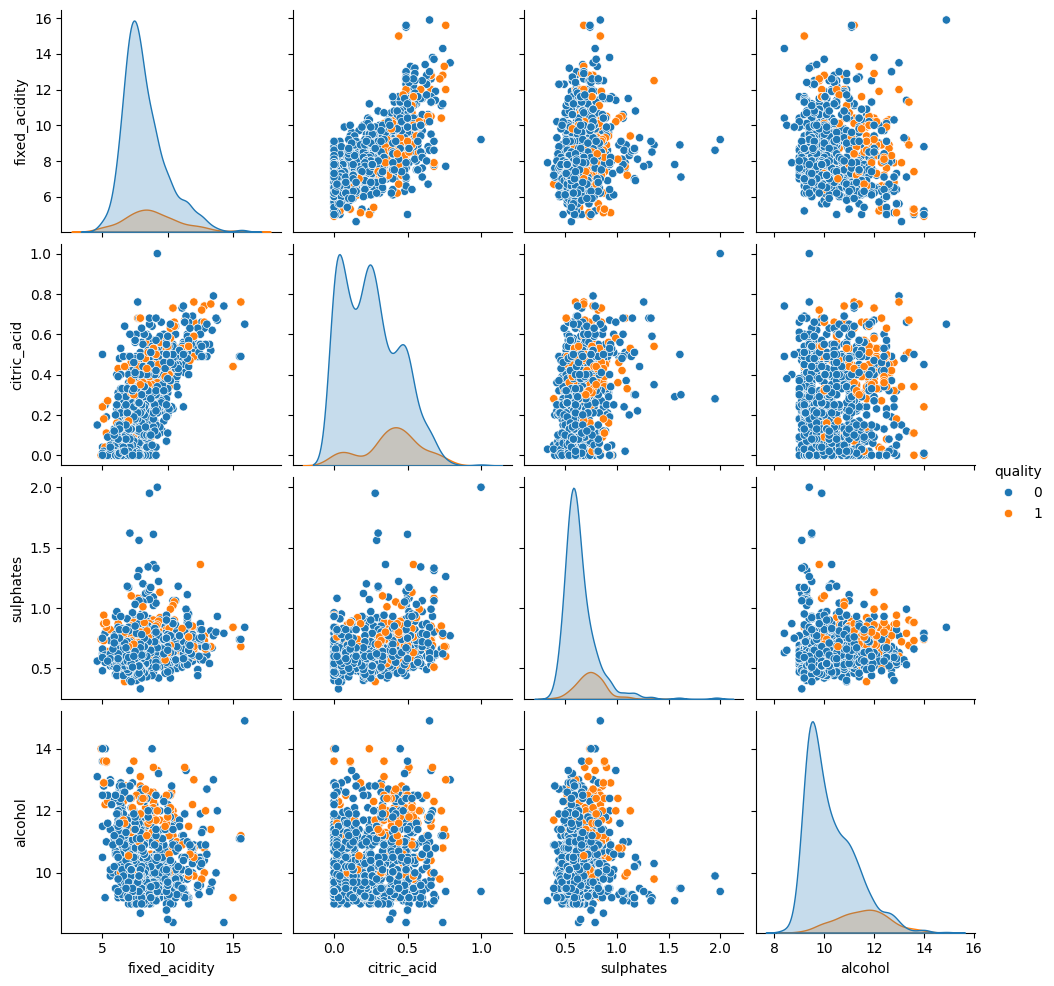

In [ ]:
sns.pairplot(df,vars=['fixed_acidity','citric_acid','sulphates','alcohol'],hue="quality")



*   Correlações entre as variáveis que possuem menor proximidade com a variável quality:



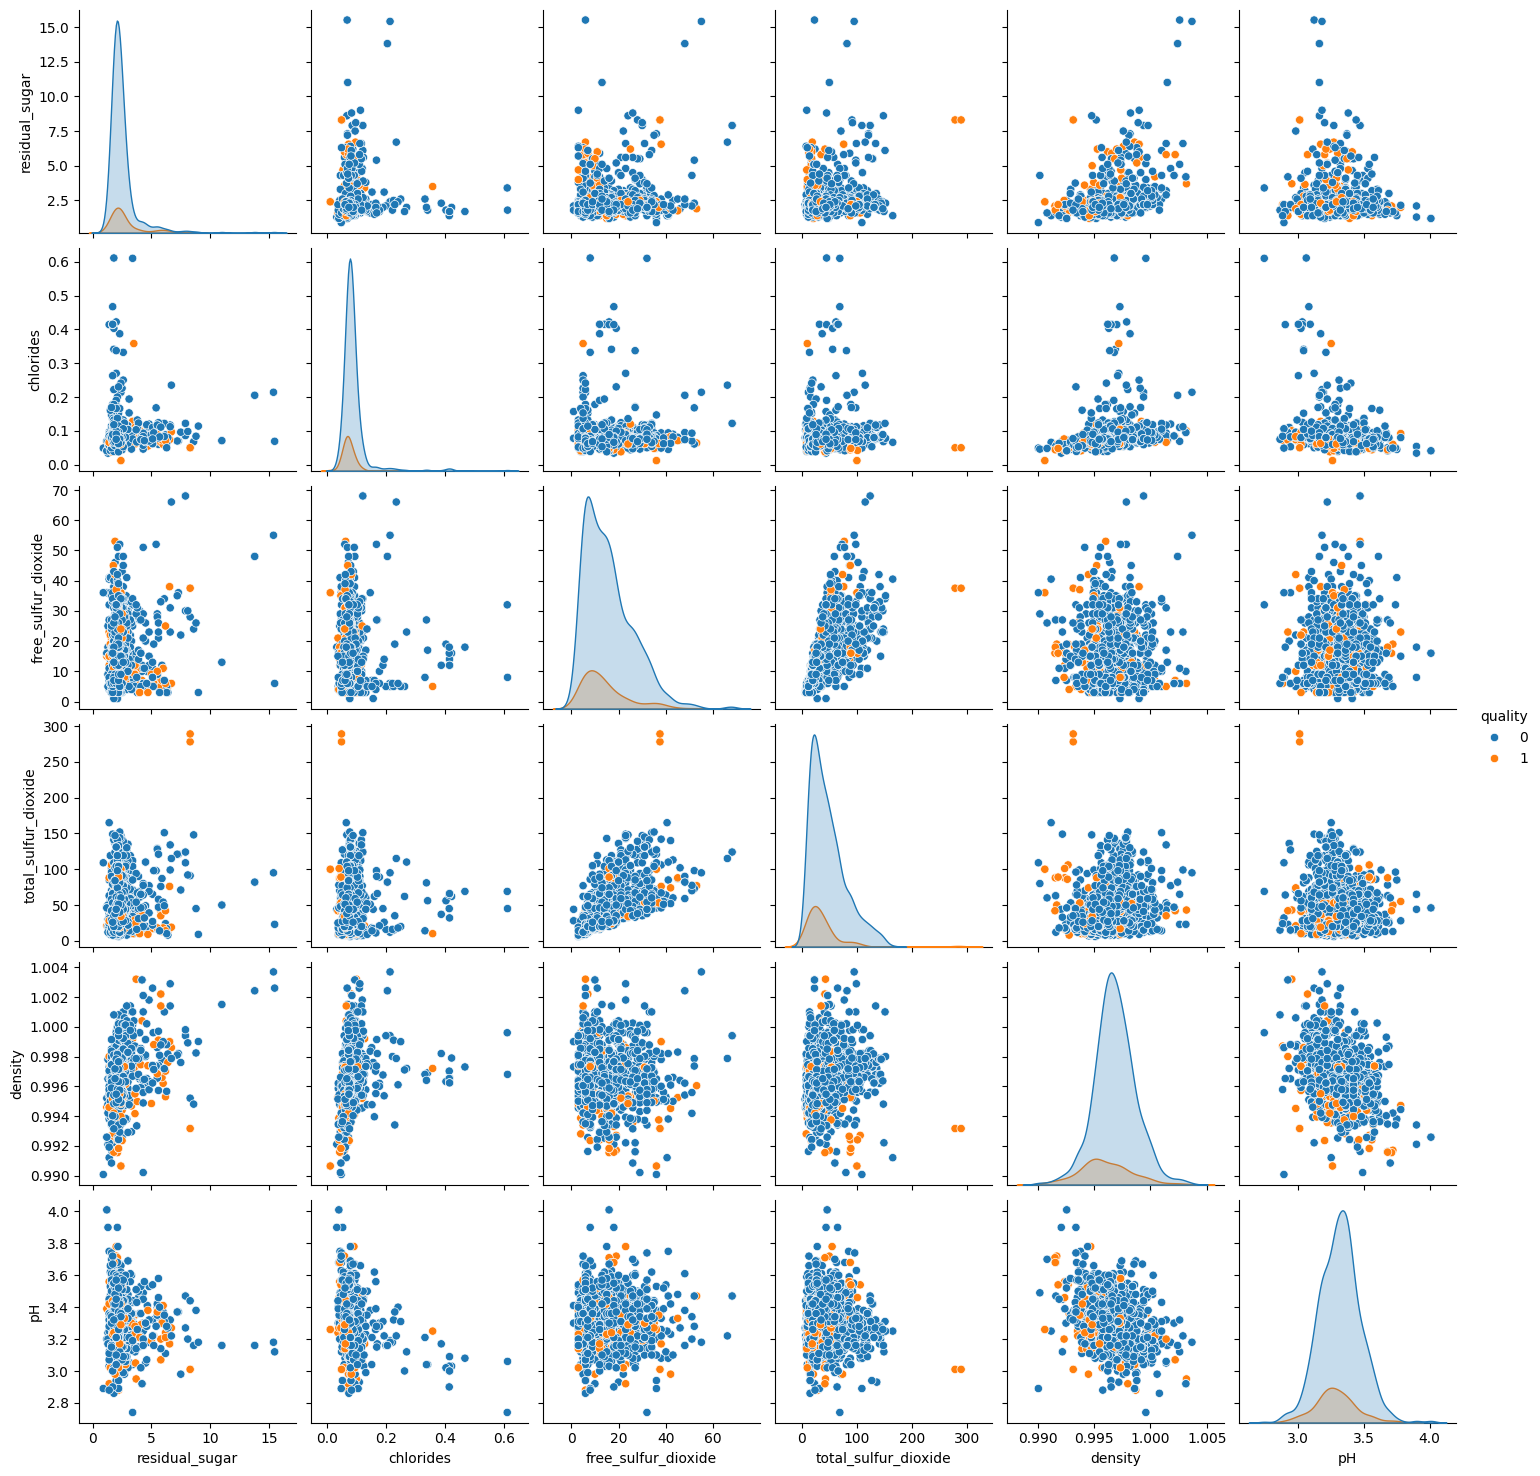

In [ ]:
sns.pairplot(df,vars=['residual_sugar','chlorides','free_sulfur_dioxide','total_sulfur_dioxide','density',
                      'pH'],hue="quality")



* Análise da relação das demais variáveis do dataset com a variável quality nos valores de escala:



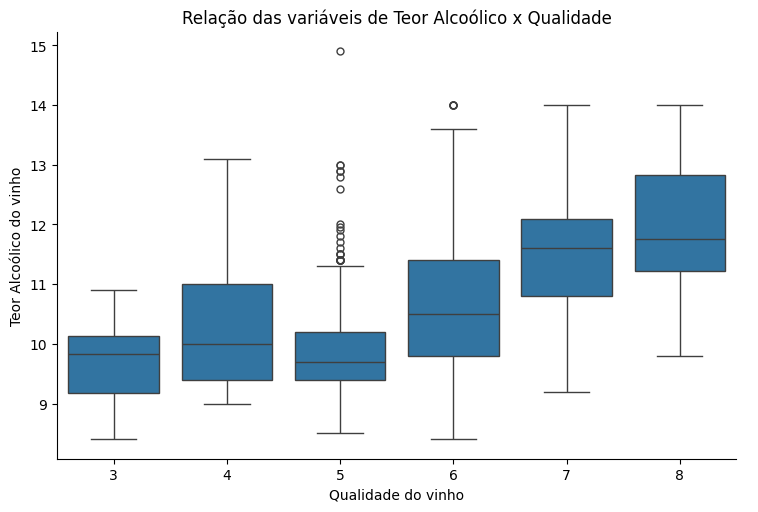

In [ ]:
#Teor Alcoólico x qualidade em escala
sns.catplot(x="quality", y="alcohol", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de Teor Alcoólico x Qualidade")
plt.ylabel("Teor Alcoólico do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

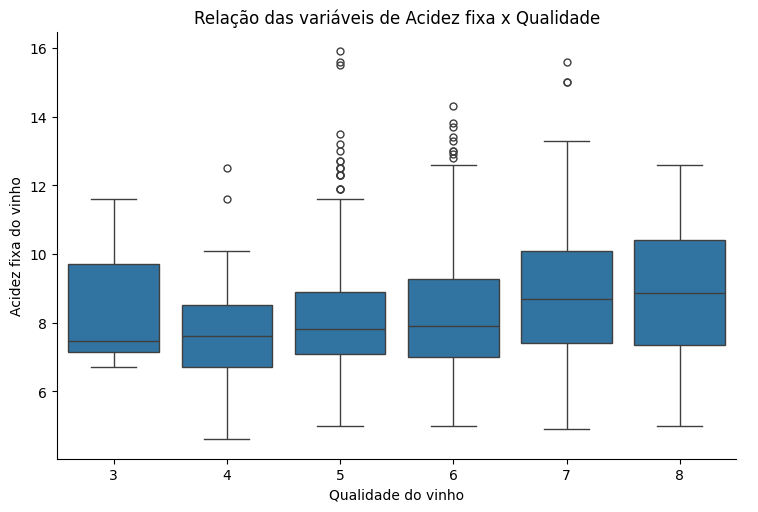

In [ ]:
#Acidez fixa x qualidade em escala
sns.catplot(x="quality", y="fixed_acidity", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de Acidez fixa x Qualidade")
plt.ylabel("Acidez fixa do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

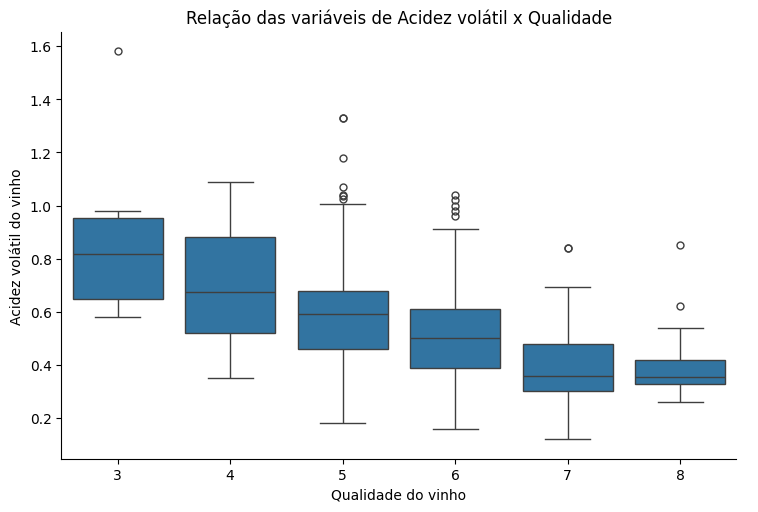

In [ ]:
#Acidez volátil x qualidade em escala
sns.catplot(x="quality", y="volatile_acidity", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de Acidez volátil x Qualidade")
plt.ylabel("Acidez volátil do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

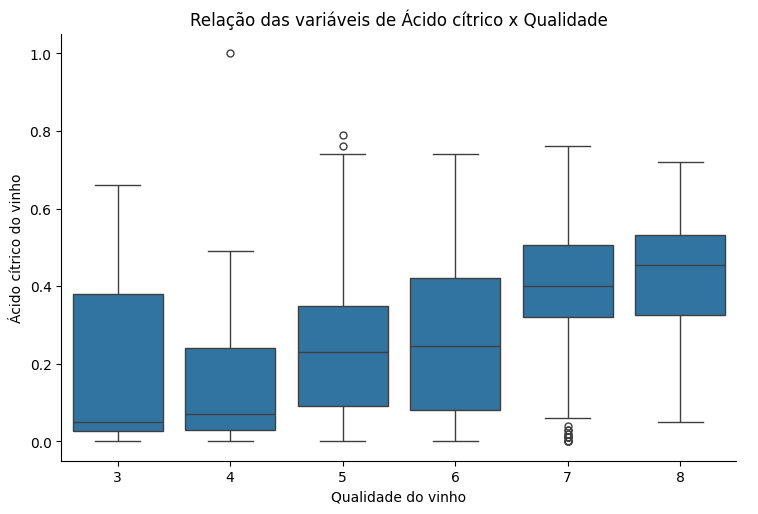

In [ ]:
#Ácido cítrico x qualidade em escala
sns.catplot(x="quality", y="citric_acid", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de Ácido cítrico x Qualidade")
plt.ylabel("Ácido cítrico do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

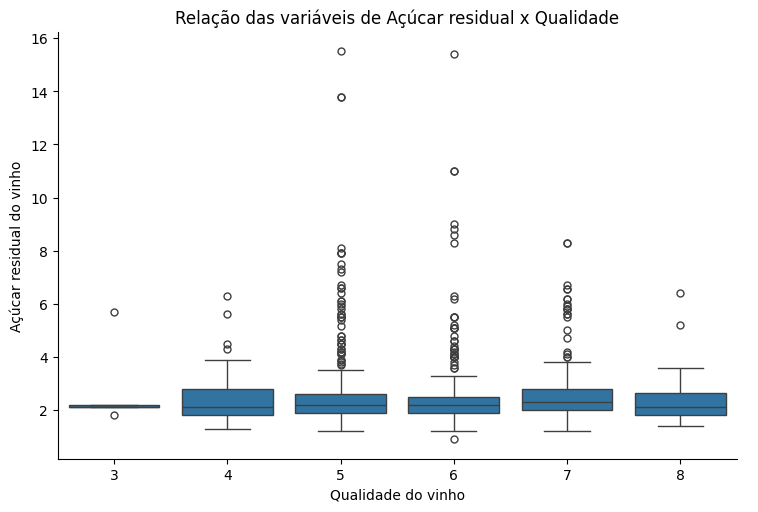

In [ ]:
#"Açúcar residual x qualidade em escala
sns.catplot(x="quality", y="residual_sugar", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de Açúcar residual x Qualidade")
plt.ylabel("Açúcar residual do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

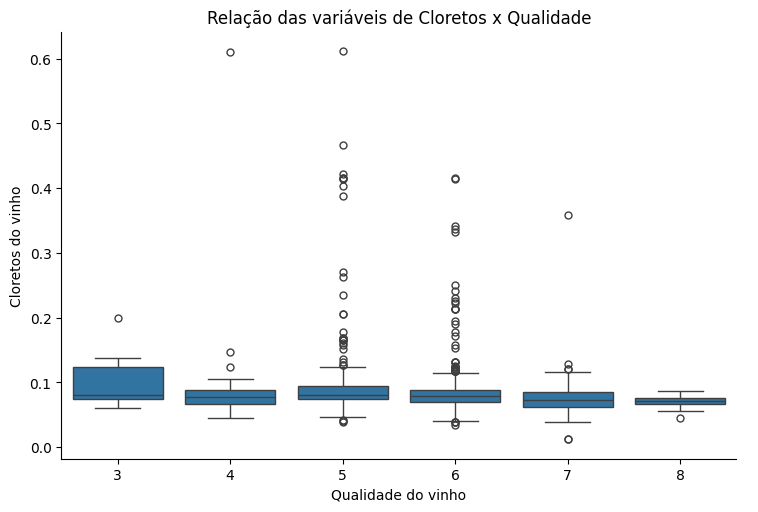

In [ ]:
#Cloretos x qualidade em escala
sns.catplot(x="quality", y="chlorides", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de Cloretos x Qualidade")
plt.ylabel("Cloretos do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

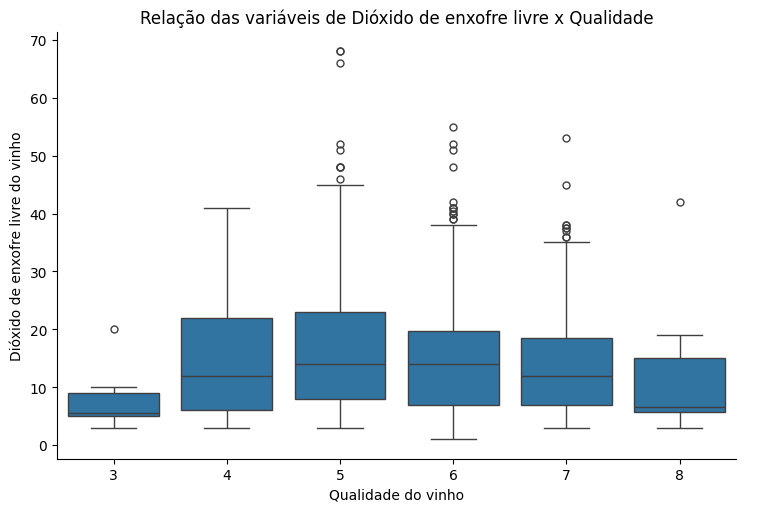

In [ ]:
#Dióxido de enxofre livre x qualidade em escala
sns.catplot(x="quality", y="free_sulfur_dioxide", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de Dióxido de enxofre livre x Qualidade")
plt.ylabel("Dióxido de enxofre livre do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

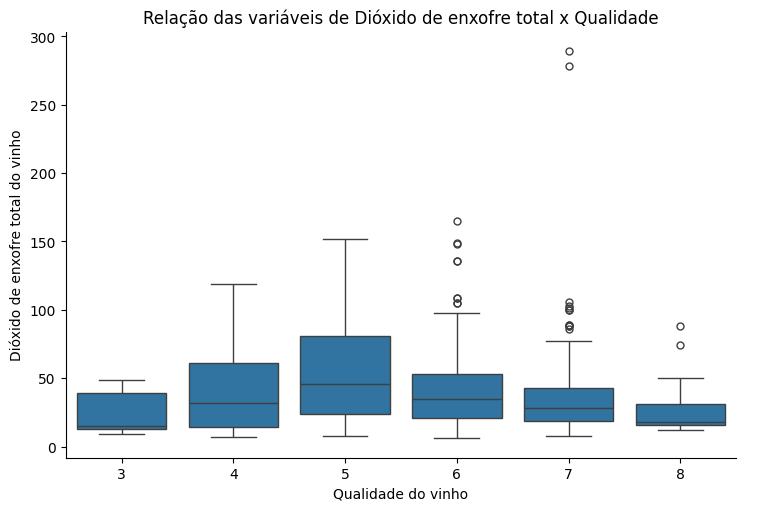

In [ ]:
#Dióxido de enxofre total x qualidade em escala
sns.catplot(x="quality", y="total_sulfur_dioxide", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de Dióxido de enxofre total x Qualidade")
plt.ylabel("Dióxido de enxofre total do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

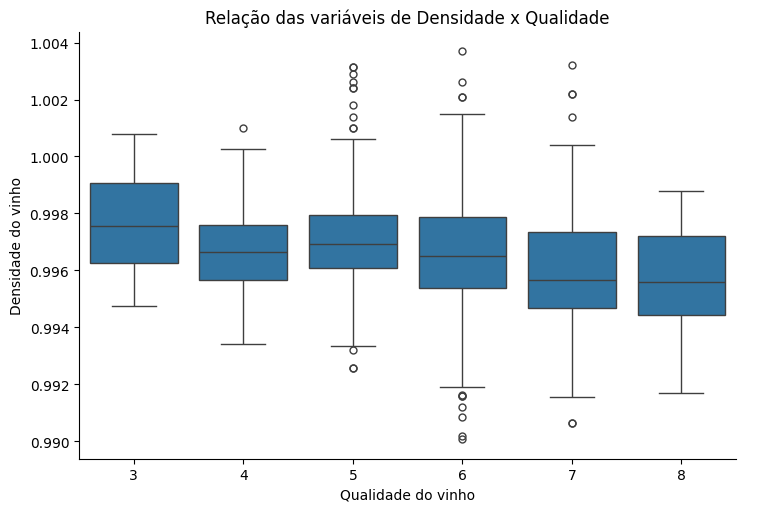

In [ ]:
#Densidade x qualidade em escala
sns.catplot(x="quality", y="density", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de Densidade x Qualidade")
plt.ylabel("Densidade do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

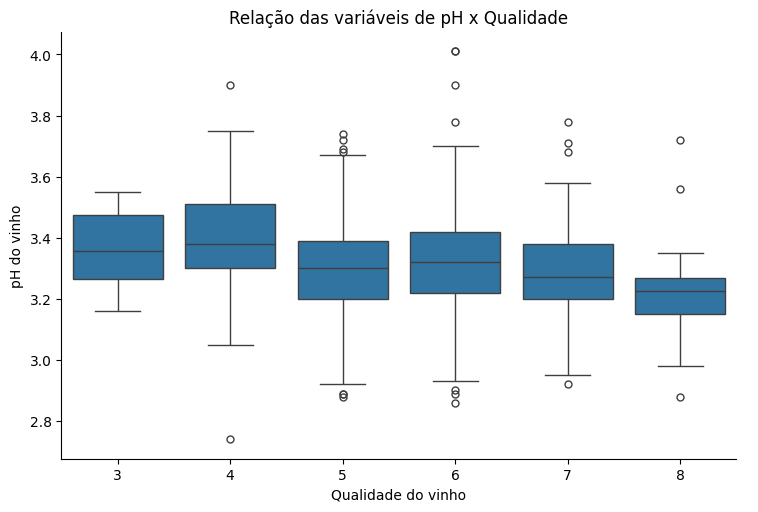

In [ ]:
#pH x qualidade em escala
sns.catplot(x="quality", y="pH", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de pH x Qualidade")
plt.ylabel("pH do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

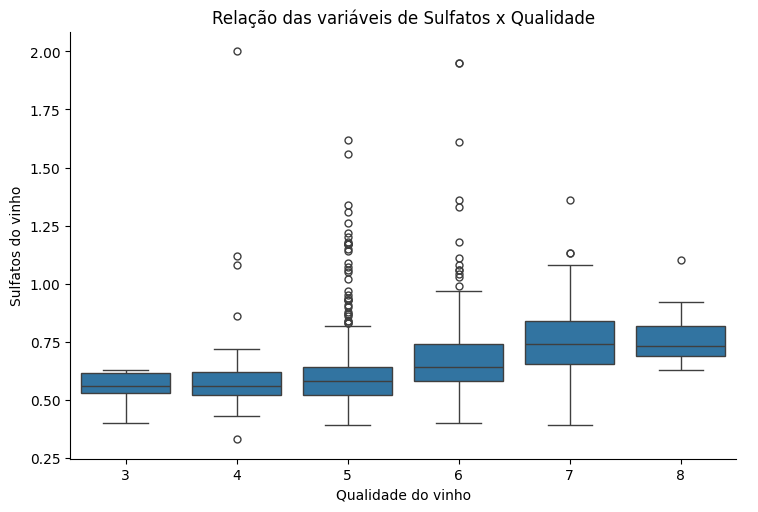

In [ ]:
#Sulfatos x qualidade em escala
sns.catplot(x="quality", y="sulphates", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de Sulfatos x Qualidade")
plt.ylabel("Sulfatos do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

Transformação da variável quality em binária:


*   Igual ou maior que 7 = Alta Qualidade
*   Menor que 7 = Baixa/Média Qualidade

In [ ]:
df['quality'] = (df['quality'] >= 7).astype(int)

In [ ]:
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [ ]:
df.tail()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,0
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,0
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,0
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,0
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,0


Para investigar mais detalhadamente as relações entre quality e as demais as variáveis, foram realizados novamente os gráficos de catplot, agora com a variável quality com valores binários:

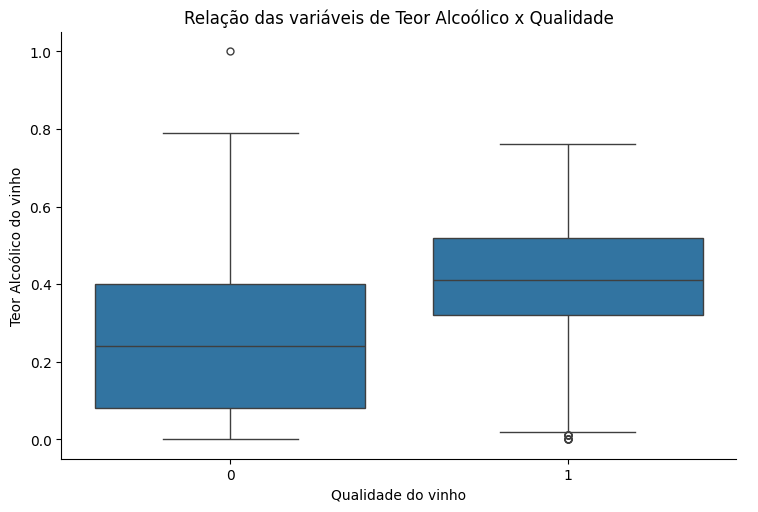

In [ ]:
#Teor alcoólico x qualidade em valores binários
sns.catplot(x="quality", y="citric_acid", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de Teor Alcoólico x Qualidade")
plt.ylabel("Teor Alcoólico do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

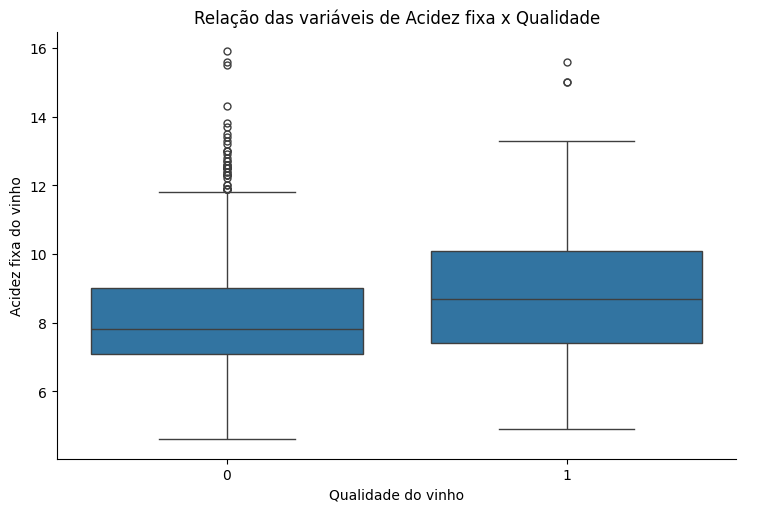

In [ ]:
#Acidez fixa x qualidade em valores binários
sns.catplot(x="quality", y="fixed_acidity", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de Acidez fixa x Qualidade")
plt.ylabel("Acidez fixa do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

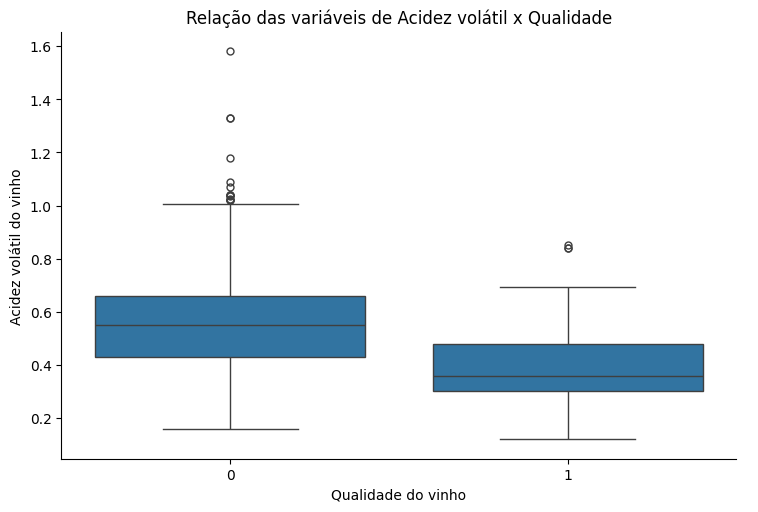

In [ ]:
#Acidez volátil x qualidade em valores binários
sns.catplot(x="quality", y="volatile_acidity", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de Acidez volátil x Qualidade")
plt.ylabel("Acidez volátil do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

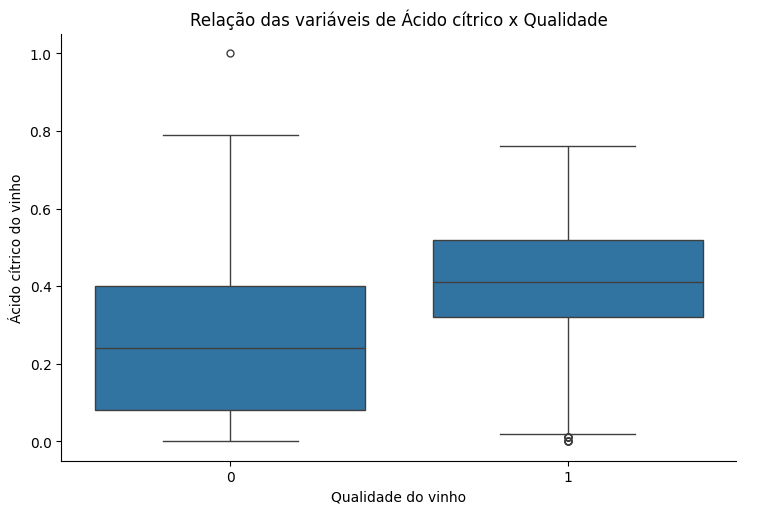

In [ ]:
#Ácido cítrico x qualidade em valores binários
sns.catplot(x="quality", y="citric_acid", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de Ácido cítrico x Qualidade")
plt.ylabel("Ácido cítrico do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

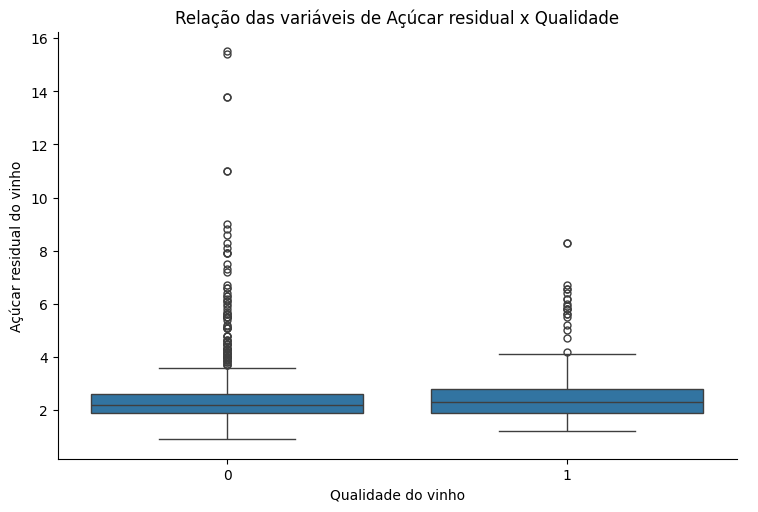

In [ ]:
#Açúcar residual x qualidade em valores binários
sns.catplot(x="quality", y="residual_sugar", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de Açúcar residual x Qualidade")
plt.ylabel("Açúcar residual do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

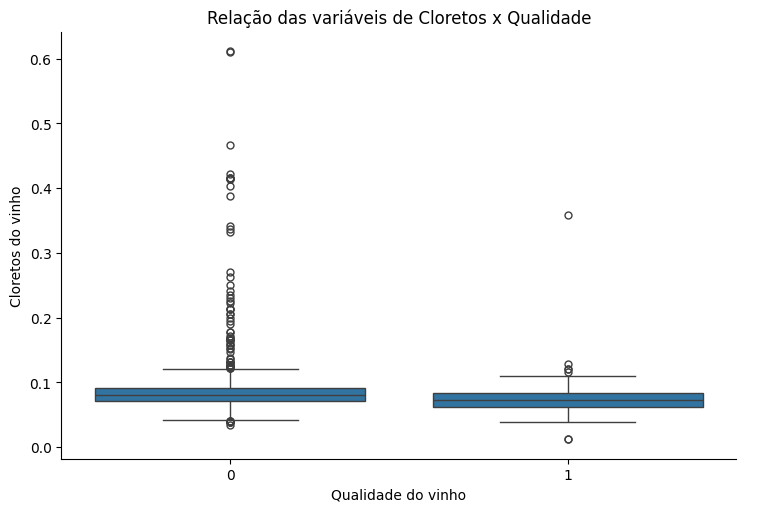

In [ ]:
#Cloretos x qualidade em valores binários
sns.catplot(x="quality", y="chlorides", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de Cloretos x Qualidade")
plt.ylabel("Cloretos do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

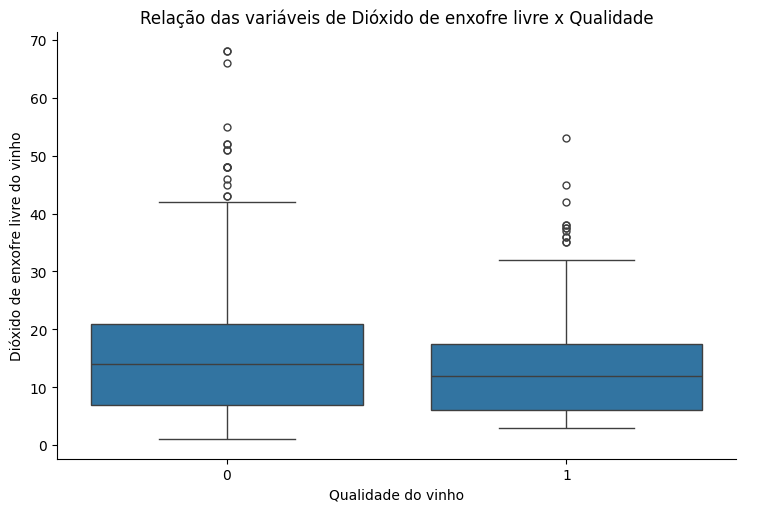

In [ ]:
#Dióxido de enxofre livre x qualidade em valores binários
sns.catplot(x="quality", y="free_sulfur_dioxide", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de Dióxido de enxofre livre x Qualidade")
plt.ylabel("Dióxido de enxofre livre do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

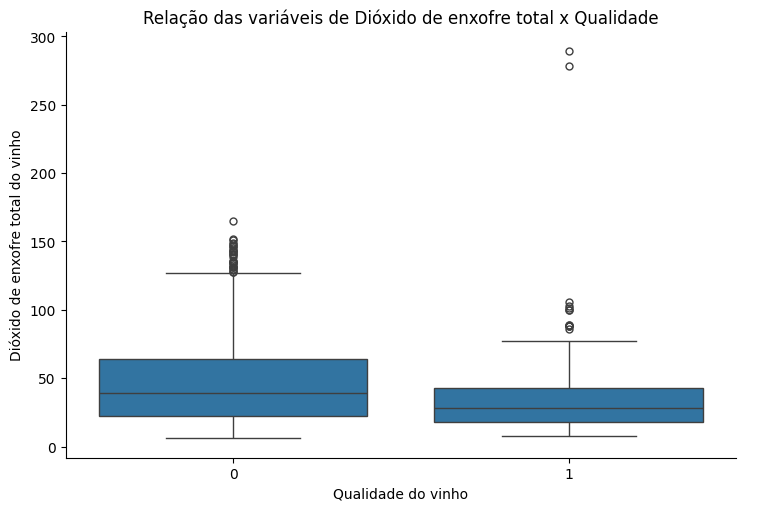

In [ ]:
#Dióxido de enxofre total x qualidade em valores binários
sns.catplot(x="quality", y="total_sulfur_dioxide", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de Dióxido de enxofre total x Qualidade")
plt.ylabel("Dióxido de enxofre total do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

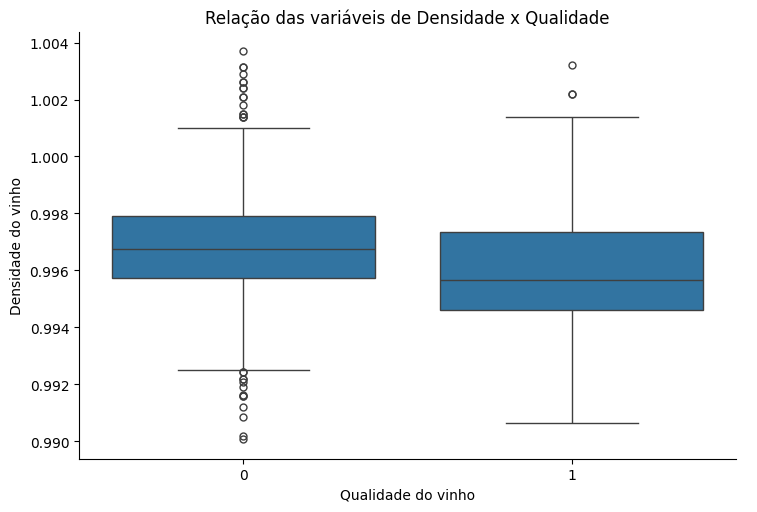

In [ ]:
#Densidade x qualidade em valores binários
sns.catplot(x="quality", y="density", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de Densidade x Qualidade")
plt.ylabel("Densidade do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

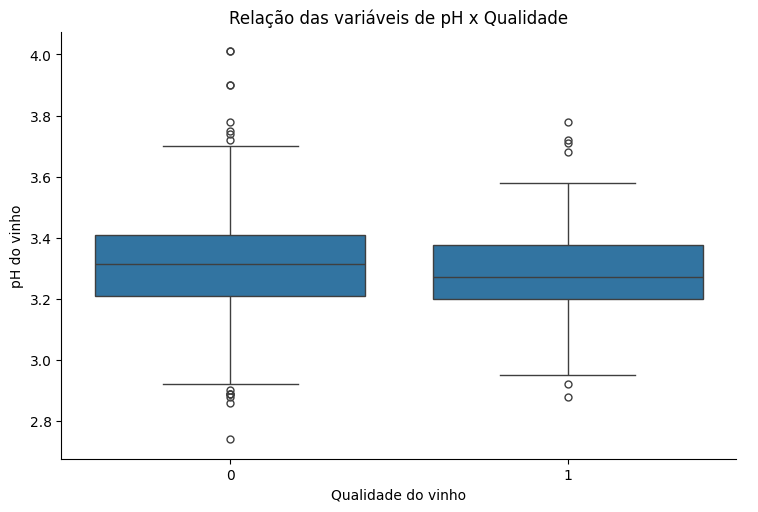

In [ ]:
#pH x qualidade em valores binários
sns.catplot(x="quality", y="pH", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de pH x Qualidade")
plt.ylabel("pH do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

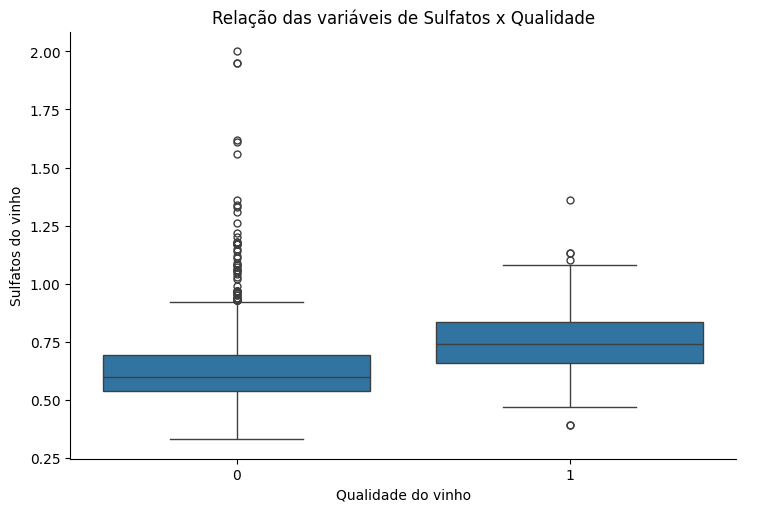

In [ ]:
#Sulfatos  x qualidade em valores binários
sns.catplot(x="quality", y="sulphates", data = df, kind = "box", aspect = 1.5)
plt.title("Relação das variáveis de Sulfatos x Qualidade")
plt.ylabel("Sulfatos do vinho")
plt.xlabel("Qualidade do vinho")
plt.show()

As variáveis “citric_acid”, “sulphates”, “alcohol”, que são mais próximas de quality, têm valores mais altos na maioria dos registros dos vinhos de alta qualidade.

Já as variáveis “residual_sugar”, “chlorides”, “free_sulfur_dioxide”, “total_sulfur_dioxide”, “density”, “pH”, que são mais distantes de quality, apresentam valores menores nos vinhos de alta qualidade ou iguais ao de menor qualidade.

Apesar de mostrar uma proximidade com quality, variável “fixed_acidity” também mostra valores menores em vinhos de maior qualidade.

Porcentagem dos vinhos:

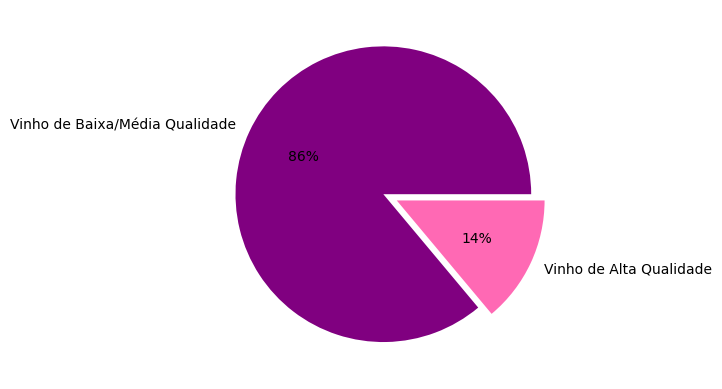

In [ ]:
categororias = ["Vinho de Baixa/Média Qualidade", "Vinho de Alta Qualidade"]
p_colors = ["purple", "hotpink"]
plt.pie(df["quality"].value_counts(), labels = categororias, autopct = "%.0f%%", explode= (0, 0.1), colors = p_colors)
plt.show()

Em geral, os vinhos de qualidade alta (com nota igual ou maior que 7) possuem menos registros, mas apresentam têm menos outliers na maioria das variáveis.

# Pré-processamento de Dados

In [ ]:
df = df.drop(columns=['Id'])



*   Separação das bases de teste e treinamento:


In [ ]:
x = df.drop(columns=['quality']) #variaveis independentes
y = df['quality'] #variável target

In [ ]:
x

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2


In [ ]:
y

,quality
0,0
1,0
2,0
3,0
4,0
...,...
1138,0
1139,0
1140,0
1141,0


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify = y, random_state=7)

In [ ]:
y_test.shape

(229,)

In [ ]:
y_train.shape

(914,)

# Modelos de Classificação

## Decision tree

In [ ]:
dt = DecisionTreeClassifier(random_state=7, criterion='entropy', max_depth = 2)

In [ ]:
dt.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=7)

In [ ]:
y_predito_dt = dt.predict(x_test)

[Text(0.5, 0.8333333333333334, 'x[10] <= 10.95\nentropy = 0.581\nsamples = 914\nvalue = [787.0, 127.0]'),
 Text(0.25, 0.5, 'x[0] <= 11.55\nentropy = 0.31\nsamples = 646\nvalue = [610, 36]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'entropy = 0.227\nsamples = 601\nvalue = [579, 22]'),
 Text(0.375, 0.16666666666666666, 'entropy = 0.894\nsamples = 45\nvalue = [31, 14]'),
 Text(0.75, 0.5, 'x[2] <= 0.295\nentropy = 0.924\nsamples = 268\nvalue = [177, 91]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'entropy = 0.525\nsamples = 118\nvalue = [104, 14]'),
 Text(0.875, 0.16666666666666666, 'entropy = 0.999\nsamples = 150\nvalue = [73, 77]')]

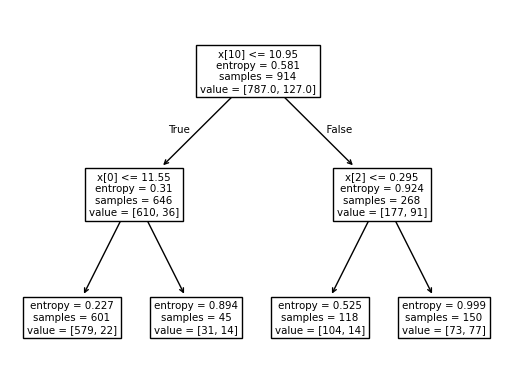

In [ ]:
tree.plot_tree(dt)

In [ ]:
print(classification_report(y_test, y_predito_dt))

              precision    recall  f1-score   support

           0       0.92      0.87      0.90       197
           1       0.40      0.53      0.46        32

    accuracy                           0.83       229
   macro avg       0.66      0.70      0.68       229
weighted avg       0.85      0.83      0.83       229



## Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=5, max_depth = 2,  class_weight = 'balanced', random_state=7)

rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=2, n_estimators=5,
                       random_state=7)

In [ ]:
estimator = rf.estimators_

In [ ]:
y_predito_rf = rf.predict(x_test)

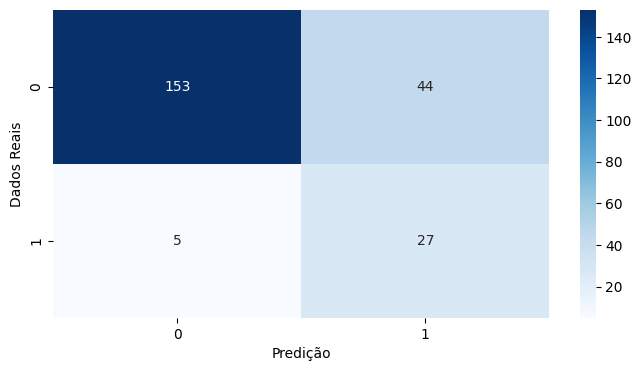

In [ ]:
matriz_confusao = confusion_matrix(y_test, y_predito_rf)
plt.figure(figsize = (8, 4))
sns.heatmap(matriz_confusao, annot = True, fmt="d",cmap = "Blues")
plt.xlabel("Predição");
plt.ylabel("Dados Reais");

In [ ]:
print(classification_report(y_test, y_predito_rf))

              precision    recall  f1-score   support

           0       0.97      0.78      0.86       197
           1       0.38      0.84      0.52        32

    accuracy                           0.79       229
   macro avg       0.67      0.81      0.69       229
weighted avg       0.89      0.79      0.81       229



Para tentar melhorar os resultados do Random Forest, o SMOTE será utilizado para equilibrar as classes:

In [ ]:
oversample = SMOTE()
x_train_os, y_train_os = oversample.fit_resample(x_train, y_train)

In [ ]:
x_train.shape

(914, 11)

In [ ]:
x_train_os.shape

(1574, 11)

In [ ]:
rf = RandomForestClassifier(criterion= 'entropy', n_estimators=80, max_depth = 7, class_weight = 'balanced', random_state=7)

rf.fit(x_train_os, y_train_os)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=7, n_estimators=80, random_state=7)

In [ ]:
estimator_rf = rf.estimators_

In [ ]:
y_predito_random_forest = rf.predict(x_test)

In [ ]:
print(classification_report(y_test, y_predito_random_forest))

              precision    recall  f1-score   support

           0       0.94      0.85      0.90       197
           1       0.43      0.69      0.53        32

    accuracy                           0.83       229
   macro avg       0.69      0.77      0.71       229
weighted avg       0.87      0.83      0.84       229



## XGBoost

In [ ]:
xgb_class = xgb.XGBClassifier(random_state=7)
xgb_class.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_class.score(x_test, y_test)

0.8995633187772926

In [ ]:
y_predx = xgb_class.predict(x_test)

In [ ]:
print(classification_report(y_test, y_predx))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       197
           1       0.65      0.62      0.63        32

    accuracy                           0.90       229
   macro avg       0.79      0.78      0.79       229
weighted avg       0.90      0.90      0.90       229



## Gradient Boosted

In [ ]:
lgbm_class = lgb.LGBMClassifier(random_state=7)

In [ ]:
lgbm_class.fit(x_train, y_train)

[LightGBM] [Info] Number of positive: 127, number of negative: 787
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000327 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 957
[LightGBM] [Info] Number of data points in the train set: 914, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.138950 -> initscore=-1.824041
[LightGBM] [Info] Start training from score -1.824041
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(random_state=7)

In [ ]:
lgbm_class.score(x_test, y_test)

0.8951965065502183

In [ ]:
y_preds = lgbm_class.predict(x_test)

In [ ]:
print(f1_score(y_test, y_preds))

0.625


In [ ]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       197
           1       0.62      0.62      0.62        32

    accuracy                           0.90       229
   macro avg       0.78      0.78      0.78       229
weighted avg       0.90      0.90      0.90       229

